# Regression

## Libraries

In [1]:
from sklearn.model_selection import train_test_split

from Project3.nn.activation import Activation
from Project3.nn.train_mode import TrainMode
from Project3.nn.weight_init import WeightInit
from data_provider import load_data, normalize_data
from nn.nnr import NeuralNetworkRegression
from visualizer import plot_regression_results as visualize

## 1. Data Loading and Splitting

In [2]:
# Random
rs = 67  # SIX SEVEN

# Loading data
XX = 11
path = f"dane/dane{XX}.txt"
X, y = load_data(path)

# Splitting
X_train, X_test, y_train, y_test = normalize_data(train_test_split(X, y, test_size=0.2, random_state=rs))

## 2. Neural Network Design and Training

### Check [nnr.py](nn/nnr.py) for implementation

## 3. Network Evaluation - overfitting/underfitting

### 3.1 Underfitting

10.0%
20.0%
30.0%
40.0%
50.0%
60.0%
70.0%
80.0%
90.0%


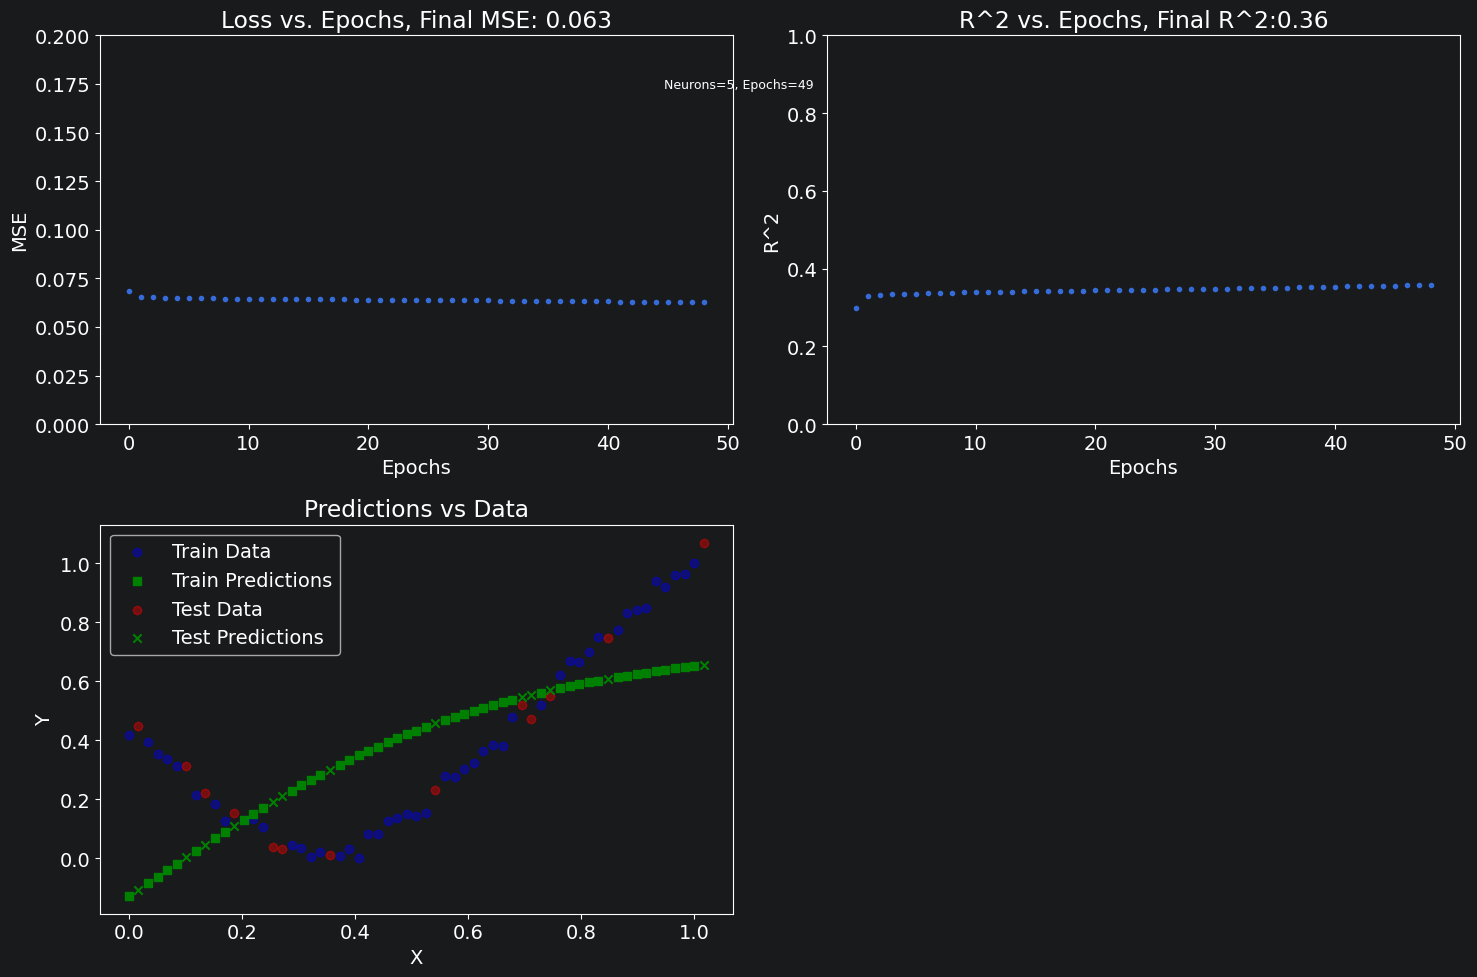

In [11]:
nn_underfit = NeuralNetworkRegression(hidden_size=5)
nn_underfit.train(X_train, y_train, epochs=50)

visualize(nn_underfit, X_train, y_train, X_test, y_test, title="Regressor batch underfitting")

### 3.2 Optimal

10.0%
20.0%
Training stopped, R^2 score reached 0.95


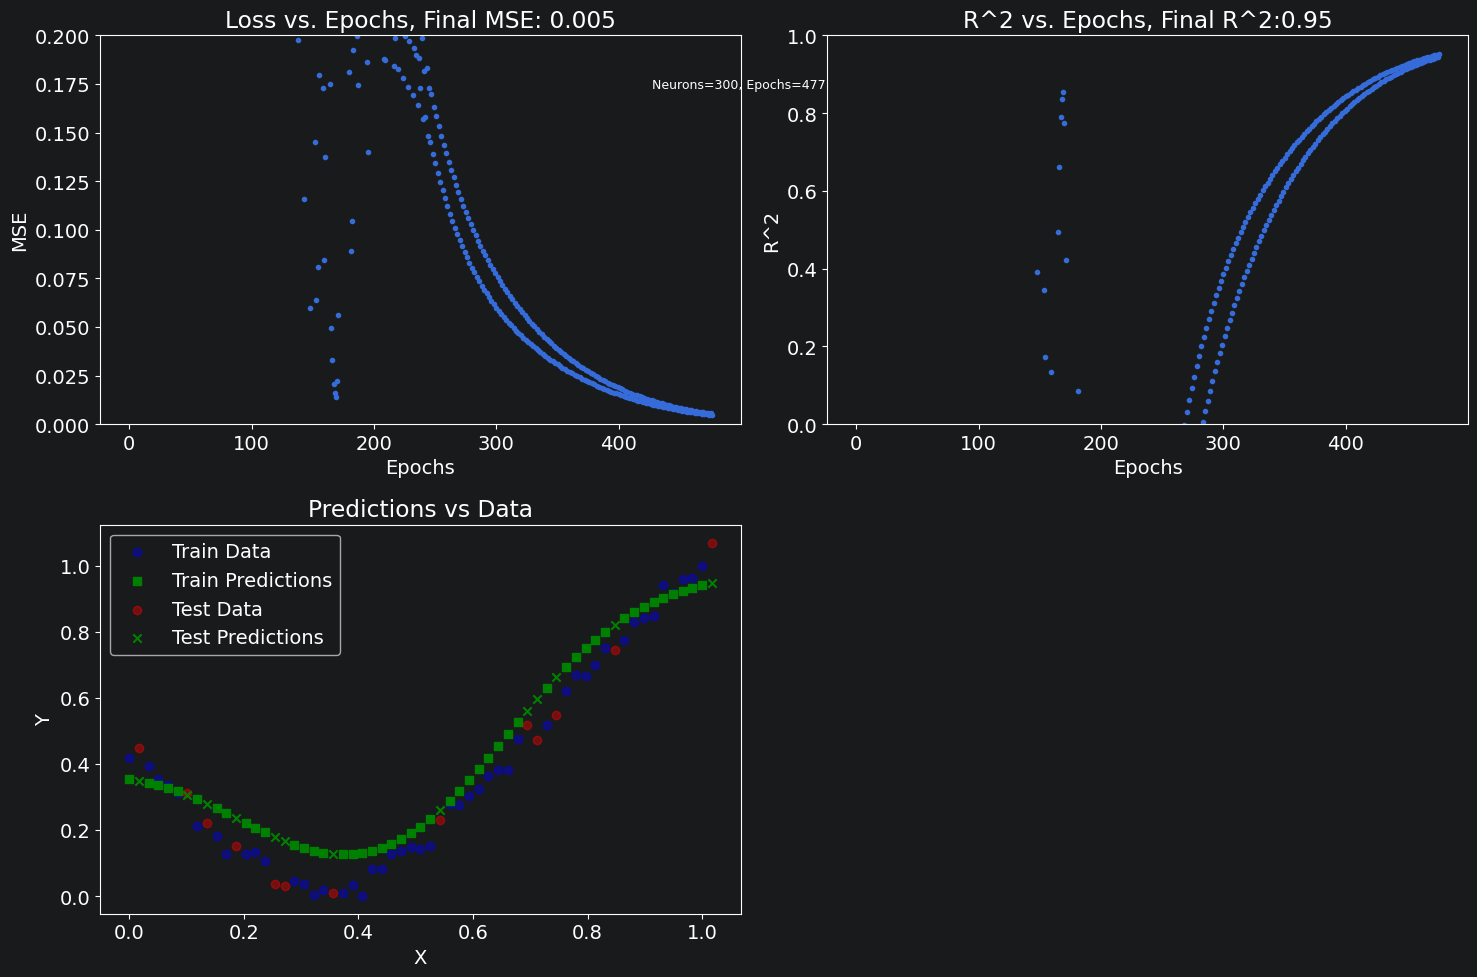

In [12]:
nn_optimal = NeuralNetworkRegression(hidden_size=300)
nn_optimal.train(X_train, y_train, epochs=2000)

visualize(nn_optimal, X_train, y_train, X_test, y_test, title="Regressor batch optimal")

### 3.3 Overfitting

10.0%
20.0%
30.0%
40.0%
50.0%
60.0%
70.0%
80.0%
90.0%


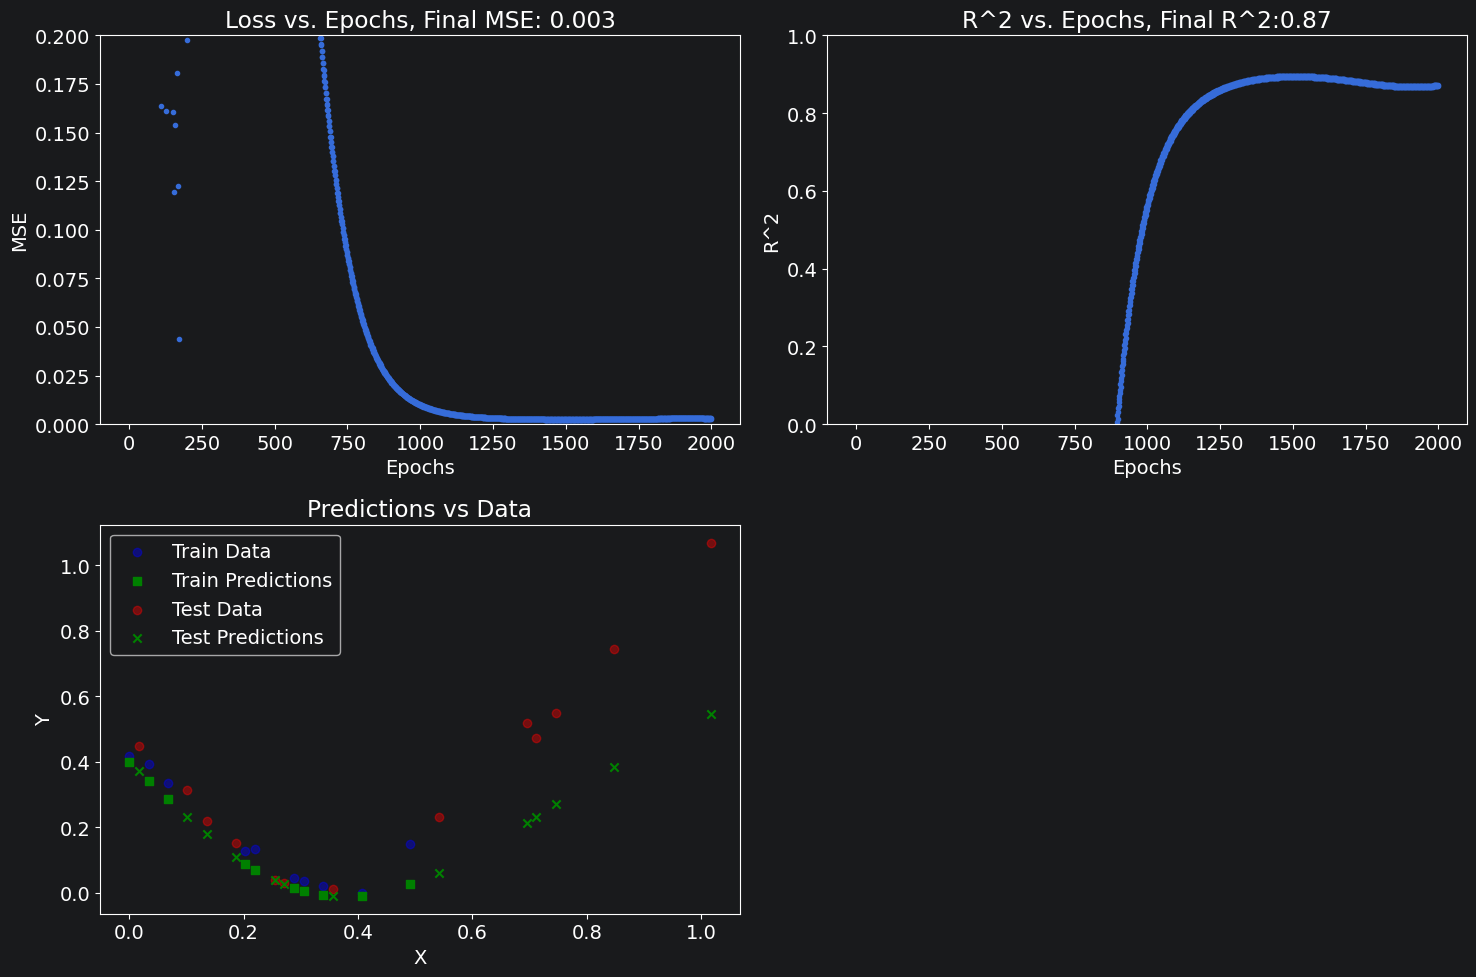

In [9]:
mask = X_train[:, 0] < 0.5
X_train_tiny = X_train[mask][:10]
y_train_tiny = y_train[mask][:10]

nn_overfit = NeuralNetworkRegression(hidden_size=300)
nn_overfit.train(X_train_tiny, y_train_tiny, epochs=2000, learning_rate=0.01, reg_lambda=0.0)

visualize(nn_overfit, X_train_tiny, y_train_tiny, X_test, y_test, title="Regressor batch overfitting")

## 4. Change Training Method

10.0%
20.0%
30.0%
40.0%
50.0%
60.0%
70.0%
80.0%
90.0%


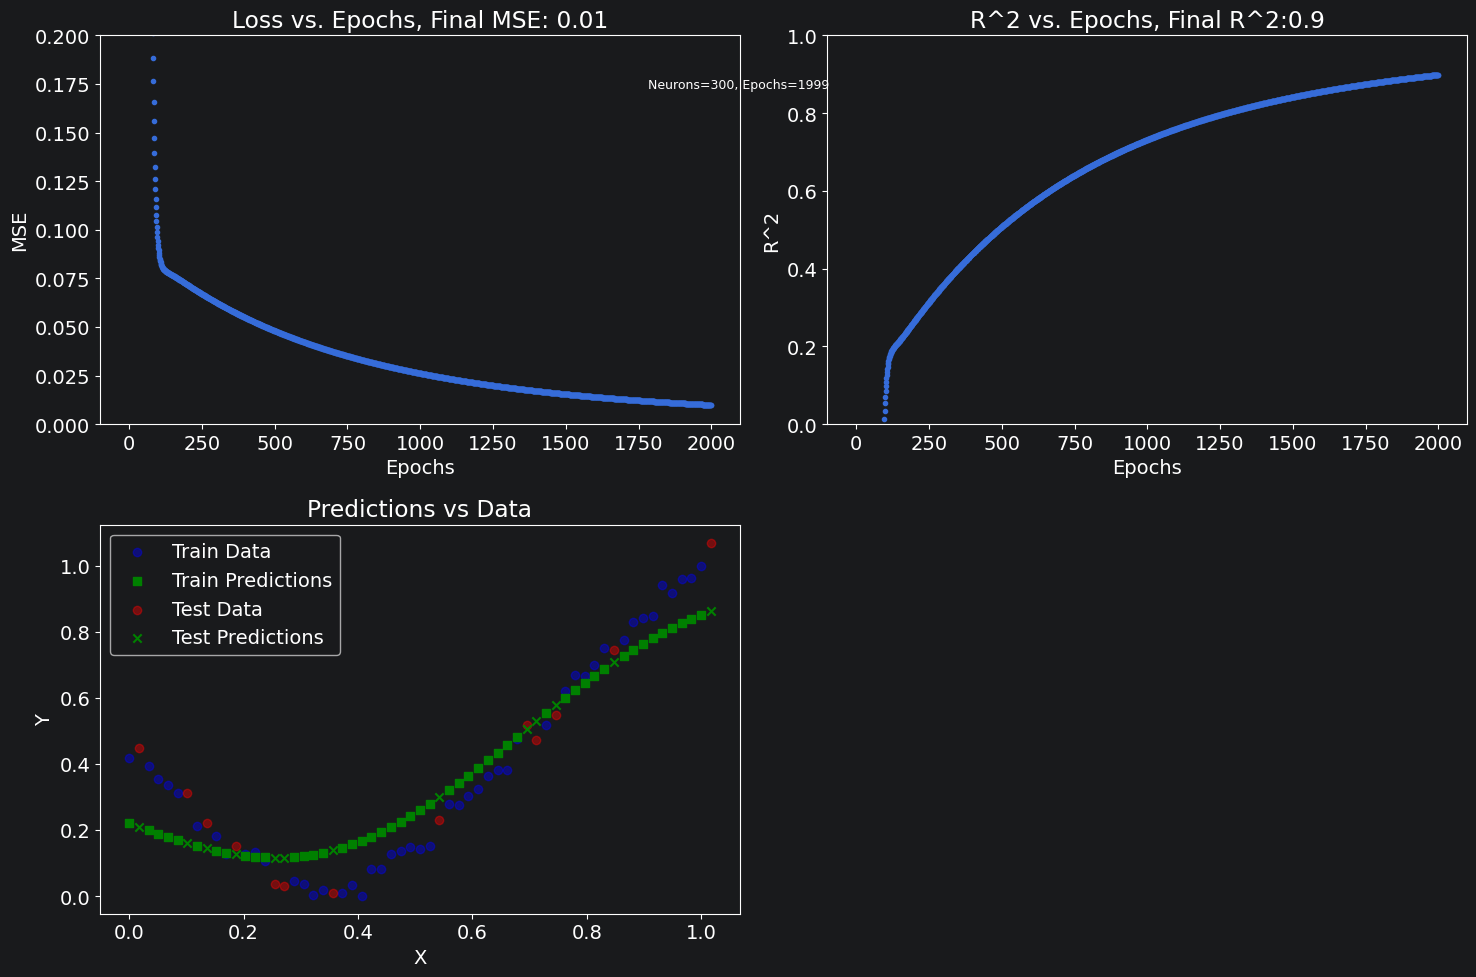

In [20]:
nn_stochastic = NeuralNetworkRegression(train_mode=TrainMode.STOCHASTIC)
nn_stochastic.train(X_train, y_train, epochs=2000, learning_rate=0.00005)

visualize(nn_stochastic, X_train, y_train, X_test, y_test, title="Regressor stochastic")

## 5. RELU Activation Function

10.0%
Training stopped, R^2 score reached 0.95


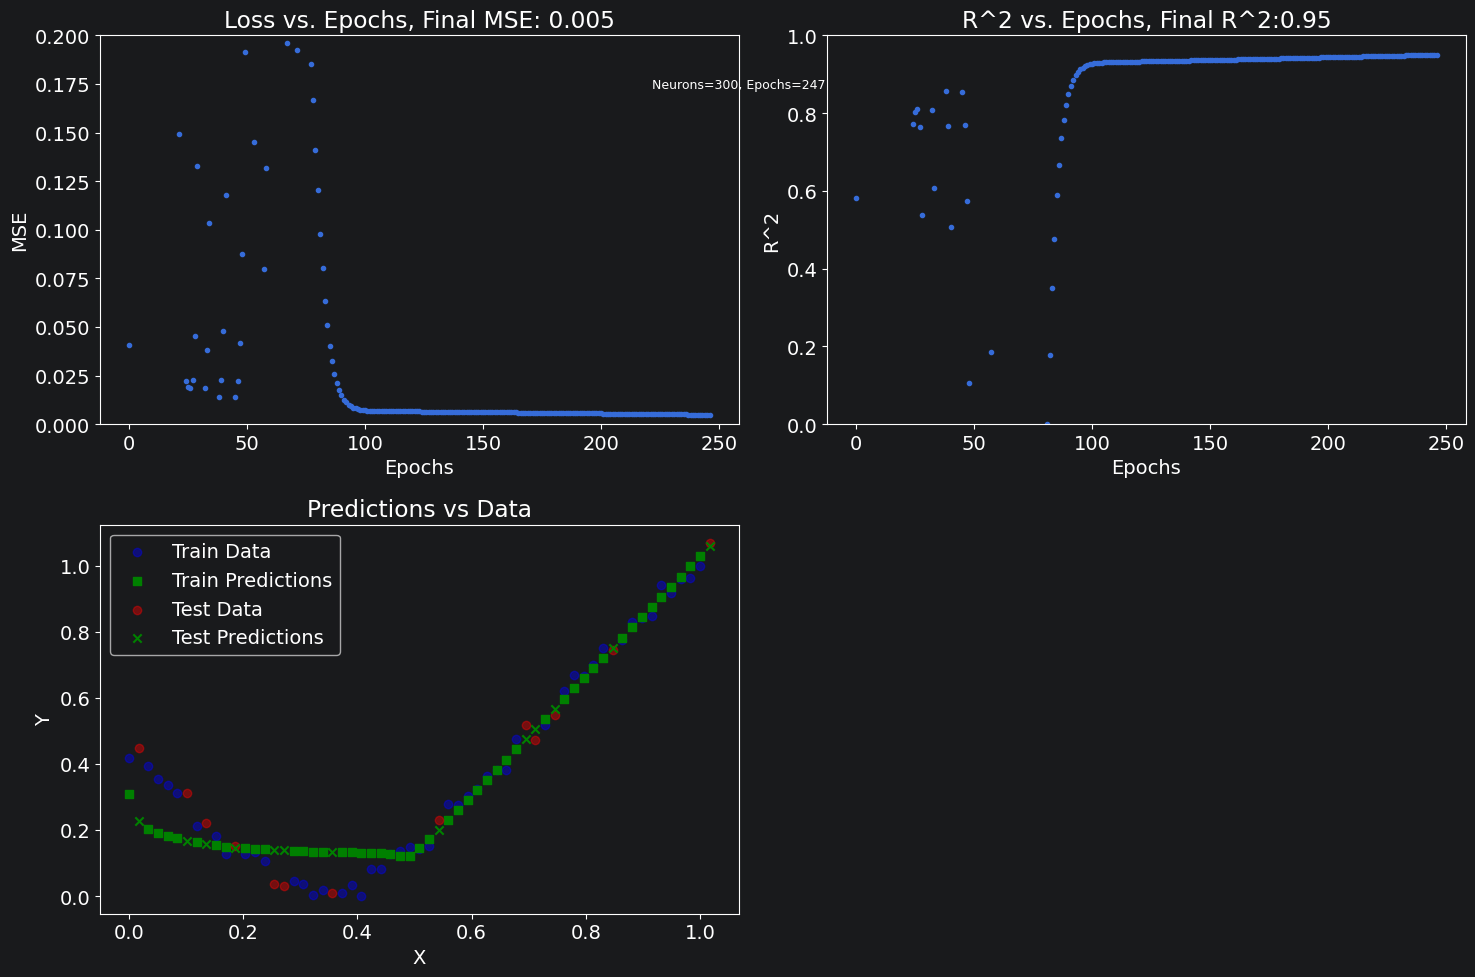

In [19]:
nn_relu = NeuralNetworkRegression(activation=Activation.RELU, weight_init=WeightInit.HE)
nn_relu.train(X_train, y_train, epochs=2000)

visualize(nn_relu, X_train, y_train, X_test, y_test, title="Regressor ReLU")